# Capacity, utilization, and operating cost

CPU companion; no accelerator is required. TPU execution not validated.

- Measure end-to-end local service time at more than one workload length.
- Compute offered load, worker reserve and illustrative cost with consistent units.
- Identify assumptions that prevent a CPU fixture from establishing accelerator fleet capacity.

A short local training job finishes quickly. How many workers would a stream of jobs require, and what can this measurement actually tell us about cost? We will measure complete CPU jobs of several lengths, separate update work from startup overhead and apply transparent capacity arithmetic to explicitly hypothetical arrival rates and prices.

## The idea

Operating cost depends on resource allocation, runtime and the billing model. A workload's fraction of time in useful updates is not the same as device utilization. Keep cost accounting and performance measurements explicit.

## Account for billed time as well as useful work

A job may spend time provisioning, loading, compiling, updating and shutting down. For short jobs, fixed startup costs can dominate even if the update loop is efficient. Reusing a warm service changes that tradeoff but introduces its own allocation costs.

Track the resource count and billed interval under the actual pricing assumptions. If a rate is hypothetical, label the resulting cost as modeled. A duration multiplied by an assumed price is not an invoice.

The timing panels compare different intervals. Their ratios can describe job-level busy fraction, but they do not measure accelerator instruction or memory utilization. Choose the metric that answers the operational question before optimizing it.

### Pause and reason

Can a high fraction of time in the update loop prove high accelerator utilization?

<details><summary>Compare your reasoning</summary>

No. The loop can wait on data, synchronization or inefficient kernels. Device utilization requires suitable device observations in addition to job timing.

</details>

## Measure the service boundary you intend to provision

We run jobs with $8$, $32$ and $64$ updates in fresh child processes. Supervisor wall time includes imports, runtime startup, compilation, updates, logs and checkpoints. If a production worker stays warm across many jobs, this measurement overstates repeated startup cost; if production adds queueing or remote data, it understates those delays. Write the boundary alongside the number. We use the maximum of these three local observations as an illustrative conservative input, not a statistical tail estimate.

## Convert seconds into worker demand

Let $\lambda$ be arrivals per hour, $t$ seconds per job and $m$ workers, each running one job at a time. Offered demand is $\lambda t/3600$ worker-hours per hour. Nominal load is this demand divided by $m$. The units cancel to a fraction. A load above one means average demand exceeds nominal capacity under the model; a load below one does not guarantee a latency target.

$$
\rho=\frac{\lambda t}{3600m}
$$

## State the reserve rather than hiding it

For reserve fraction $r$, require nominal load no greater than $1-r$. The smallest integer worker count in this simple model is the ceiling below, with at least one worker in our function. For $90$-second jobs arriving $80$ times an hour, demand is $2$ worker-hours per hour. A $25$% reserve requires at least $3$ workers; four workers would run at nominal load $0.5$.

$$
m_{\min}=\left\lceil\frac{\lambda t}{3600(1-r)}\right\rceil
$$

## A cost number needs a declared price model

We use an invented planning rate of $1.50$ currency units per worker-hour, explicitly not a current cloud price. Reserving two workers for an hour costs $3$ under that model, whether busy or idle. A job’s active-time cost is $pt/3600$ for hourly rate $p$, but dividing the reserved hourly bill by actual completed jobs can produce a different cost per completion. Include idle capacity, failed attempts, storage and transfer charges when those belong to the real budget.

## Do not confuse duty fraction with hardware utilization

The worker records seconds inside synchronized compiled updates. Dividing their sum by job wall time is an application duty fraction. A small value in a tiny job mostly reflects startup and operational overhead. It does not measure CPU core occupancy, accelerator compute utilization, memory-bandwidth pressure or scheduler allocation. Those require their own target-specific measurements. Increasing update count can amortize startup without making each update intrinsically faster.

## Capacity is a distribution, not just a mean

Real arrivals can burst, job durations can vary, failures consume retries, and a worker may be unavailable. Three short measurements cannot estimate a high percentile reliably. Retain individual timings, choose a larger representative study on the actual target, and test the queue/latency objective before buying capacity. The local examples execute real jobs; all arrival, reserve and price scenarios remain labeled assumptions.

## Create the local artifact helpers

Create main.py with this block. Run python3 main.py in the CPU course environment.

In [1]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

The only filesystem writes are to the caller-selected run directory. Stable JSON encoding makes hashes reproducible.

## Define the supervised worker

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [2]:
# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

The string is a real Python program launched in a separate process. It emits structured events, synchronizes JAX updates and preserves complete state.

## Add bounded launch and result collection

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [3]:
def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

The supervisor owns the child handle, captures its output and always waits for termination after a timeout.

## Add metric summaries and capacity arithmetic

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [4]:
def summarize(result):
    updates=[e for e in result['events'] if e['event']=='progress']
    checkpoints=[e['step'] for e in result['events'] if e['event']=='checkpoint']
    count=sum(e['examples'] for e in updates);update_s=sum(e['update_s'] for e in updates)
    latest=max((e['step'] for e in updates),default=0)
    checkpoint=max(checkpoints,default=0)
    return dict(status=result['status'],updates=len(updates),examples=count,last_step=latest,checkpoint_step=checkpoint,
                uncheckpointed_updates=max(0,latest-checkpoint),update_s=update_s,
                update_examples_per_s=count/update_s if update_s else 0.,
                job_examples_per_s=count/result['wall_s'] if result['wall_s'] else 0.,
                update_duty_fraction=update_s/result['wall_s'] if result['wall_s'] else 0.)

def capacity(measured_job_s, arrivals_per_hour, workers, hourly_rate, reserve_fraction=.25):
    """Illustrative one-job-per-worker plan; inputs are not cloud price discovery."""
    values=[measured_job_s,arrivals_per_hour,hourly_rate,reserve_fraction]
    if any(not math.isfinite(x) for x in values) or measured_job_s <= 0 or arrivals_per_hour < 0 or hourly_rate < 0:
        raise ValueError('invalid finite capacity inputs')
    if not isinstance(workers,int) or isinstance(workers,bool) or workers < 1 or not 0 <= reserve_fraction < 1:
        raise ValueError('invalid workers or reserve')
    offered=arrivals_per_hour*measured_job_s/3600
    load=offered/workers
    required=max(1,math.ceil(offered/(1-reserve_fraction)))
    return dict(offered_worker_hours_per_hour=offered,load_fraction=load,
                minimum_workers_with_reserve=required,hourly_budget=workers*hourly_rate,
                hypothetical_cost_per_job=measured_job_s*hourly_rate/3600,
                within_reserve=load <= 1-reserve_fraction)

Keep measured quantities separate from invented planning inputs and validate the units.

## Measure jobs before evaluating assumptions

Append this block to main.py. Run python3 main.py in the CPU course environment.

In [5]:
samples=[]
with tempfile.TemporaryDirectory(prefix='ops-capacity-') as folder:
    for steps in [8,32,64]:
        run=launch(Path(folder)/str(steps),dict(steps=steps))
        assert run['status']=='completed'
        samples.append((steps,run,summarize(run)))
measured=max(run['wall_s'] for _,run,_ in samples)
plan=capacity(measured_job_s=measured,arrivals_per_hour=600,workers=2,hourly_rate=1.5,reserve_fraction=.25)
assert plan['hourly_budget']==3.
print('measured local job seconds:',[r['wall_s'] for _,r,_ in samples])
print('illustrative capacity plan:',plan)
print('assumptions: 600 arrivals/hour, 2 workers, hypothetical 1.50 per worker-hour, 25% reserve')

measured local job seconds: [0.5115154590457678, 0.5084671671502292, 0.5121121248230338]
illustrative capacity plan: {'offered_worker_hours_per_hour': 0.08535202080383897, 'load_fraction': 0.042676010401919484, 'minimum_workers_with_reserve': 1, 'hourly_budget': 3.0, 'hypothetical_cost_per_job': 0.00021338005200959741, 'within_reserve': True}
assumptions: 600 arrivals/hour, 2 workers, hypothetical 1.50 per worker-hour, 25% reserve


Every duration comes from a completed child; arrival and price inputs are labeled hypothetical.

## Run the example

In [6]:
"""Bounded local JAX workload operations. No scheduler, cloud, or GPU emulator."""
from pathlib import Path
import hashlib
import json
import math
import os
import subprocess
import sys
import tempfile
import time


def digest(value):
    return hashlib.sha256(json.dumps(value, sort_keys=True, separators=(',', ':'), allow_nan=False).encode()).hexdigest()


def atomic_json(path, value):
    """Replace one local JSON file only after its bytes have been flushed."""
    path = Path(path); path.parent.mkdir(parents=True, exist_ok=True)
    fd, temporary = tempfile.mkstemp(prefix=path.name+'.', suffix='.tmp', dir=path.parent)
    try:
        with os.fdopen(fd, 'w') as stream:
            json.dump(value, stream, sort_keys=True, allow_nan=False)
            stream.flush(); os.fsync(stream.fileno())
        os.replace(temporary, path)
    finally:
        if os.path.exists(temporary): os.unlink(temporary)

# This file is materialized only inside the caller-owned temporary run folder.
WORKER = r'''
import hashlib, json, os, sys, time
from pathlib import Path
import jax
import jax.numpy as jnp
import numpy as np
root = Path(sys.argv[1])
cfg = json.loads((root/'config.json').read_text())
worker_hash = hashlib.sha256(Path(__file__).read_bytes()).hexdigest()
def emit(event, **fields):
    print(json.dumps(dict(event=event, monotonic_s=time.monotonic(), **fields)), flush=True)
def digest(value):
    return hashlib.sha256(json.dumps(value,sort_keys=True,separators=(',', ':'),allow_nan=False).encode()).hexdigest()
def write_checkpoint(state):
    target = root/'checkpoint.json'; temporary = root/'checkpoint.pending'
    with temporary.open('w') as stream:
        json.dump(dict(state,checksum=digest(state)),stream,sort_keys=True,allow_nan=False)
        stream.flush(); os.fsync(stream.fileno())
    os.replace(temporary,target)
    emit('checkpoint',step=state['step'],state_hash=digest(state))
try:
    emit('started',pid=os.getpid(),backend=jax.default_backend(),device_count=jax.device_count())
    if jax.default_backend() != cfg['backend'] or jax.device_count() < cfg['min_devices']:
        raise ValueError('runtime backend/device contract failed')
    x = jnp.linspace(-1.,1.,64); y = 2*x+1
    data_hash = digest(dict(x=np.asarray(x).tolist(),y=np.asarray(y).tolist()))
    training = {name:cfg[name] for name in ('seed','learning_rate','momentum','batch_size')}
    config_hash = digest(training)
    if cfg['resume']:
        saved = json.loads((root/'checkpoint.json').read_text())
        checksum = saved.pop('checksum',None)
        if checksum != digest(saved) or saved.get('worker_hash') != worker_hash:
            raise ValueError('checkpoint checksum/source mismatch')
        if saved['schema_version'] != 1 or saved['config_hash'] != config_hash or saved['data_hash'] != data_hash:
            raise ValueError('checkpoint provenance mismatch')
        state = saved
        step = saved['step']; params=jnp.array(saved['params']); velocity=jnp.array(saved['velocity']); key=jnp.array(saved['key'],dtype=jnp.uint32)
        if not isinstance(step,int) or isinstance(step,bool) or step < 0 or step > cfg['steps'] or params.shape != (2,) or velocity.shape != (2,) or key.shape != (2,):
            raise ValueError('invalid checkpoint state shape or step')
        if not bool(jnp.all(jnp.isfinite(params))) or not bool(jnp.all(jnp.isfinite(velocity))):
            raise ValueError('nonfinite checkpoint state')
        emit('restored',step=step,state_hash=digest(saved))
    else:
        step=0; params=jnp.zeros(2);velocity=jnp.zeros(2);key=jax.random.PRNGKey(cfg['seed'])
    def update(params,velocity,key):
        key, sample = jax.random.split(key)
        indices=jax.random.choice(sample,64,(cfg['batch_size'],),replace=False)
        objective=lambda p:jnp.mean((p[0]*x[indices]+p[1]-y[indices])**2)
        loss, grad=jax.value_and_grad(objective)(params)
        velocity=cfg['momentum']*velocity+grad
        params=params-cfg['learning_rate']*velocity
        return params,velocity,key,loss
    compiled=jax.jit(update)
    # Compile and synchronize once without consuming actual training state.
    begin=time.perf_counter();warm=compiled(params,velocity,key);jax.block_until_ready(warm)
    emit('ready',compile_warmup_s=time.perf_counter()-begin,step=step)
    while step < cfg['steps']:
        if cfg.get('stall_at') == step:
            emit('stall_injected',step=step)
            time.sleep(cfg.get('stall_seconds',10.))
        begin=time.perf_counter()
        params,velocity,key,loss=compiled(params,velocity,key);jax.block_until_ready((params,velocity,key,loss))
        elapsed=time.perf_counter()-begin;step+=1
        state=dict(schema_version=1,worker_hash=worker_hash,step=step,params=np.asarray(params).tolist(),velocity=np.asarray(velocity).tolist(),key=np.asarray(key).tolist(),config_hash=config_hash,data_hash=data_hash)
        emit('progress',step=step,loss=float(loss),examples=cfg['batch_size'],update_s=elapsed,state_hash=digest(state))
        if step % cfg['checkpoint_every'] == 0 or step == cfg['steps']:
            write_checkpoint(state)
        if cfg.get('fail_after') == step:
            raise RuntimeError('controlled failure after update')
    write_checkpoint(state)
    emit('completed',step=step,state_hash=digest(state))
except Exception as error:
    emit('failed',kind=type(error).__name__,message=str(error))
    raise SystemExit(23)
'''

def default_config(**changes):
    cfg=dict(seed=3,learning_rate=.04,momentum=.8,batch_size=8,steps=8,
             checkpoint_every=2,backend='cpu',min_devices=1,resume=False,
             fail_after=None,stall_at=None,stall_seconds=10.)
    cfg.update(changes)
    for name in ('steps','checkpoint_every','batch_size','min_devices'):
        if not isinstance(cfg[name],int) or isinstance(cfg[name],bool) or cfg[name] < 1: raise ValueError(name+' must be a positive integer')
    if cfg['batch_size'] > 64 or not 0 <= cfg['momentum'] < 1 or not 0 < cfg['learning_rate'] < 1:
        raise ValueError('invalid training configuration')
    return cfg


def launch(root, config=None, timeout=10.):
    root=Path(root);root.mkdir(parents=True,exist_ok=True)
    cfg=default_config(**(config or {}))
    if timeout <= 0: raise ValueError('timeout must be positive')
    atomic_json(root/'config.json',cfg)
    worker=root/'worker.py';worker.write_text(WORKER)
    env=dict(os.environ,JAX_PLATFORMS=cfg['backend'],PYTHONUNBUFFERED='1')
    started=time.perf_counter()
    process=subprocess.Popen([sys.executable,str(worker),str(root)],stdout=subprocess.PIPE,stderr=subprocess.PIPE,text=True,env=env)
    timed_out=False
    try:
        stdout,stderr=process.communicate(timeout=timeout)
    except subprocess.TimeoutExpired:
        timed_out=True;process.terminate()
        try: stdout,stderr=process.communicate(timeout=1.)
        except subprocess.TimeoutExpired:
            process.kill();stdout,stderr=process.communicate(timeout=1.)
    wall=time.perf_counter()-started
    events=[]; malformed=[]
    for line in stdout.splitlines():
        if not line.strip(): continue
        try:
            event=json.loads(line)
            if not isinstance(event,dict) or 'event' not in event: raise ValueError('not an event')
            events.append(event)
        except (ValueError,TypeError): malformed.append(line)
    status='timed_out' if timed_out else 'completed' if process.returncode == 0 and not malformed and events and events[-1]['event']=='completed' else 'failed'
    result=dict(status=status,returncode=process.returncode,wall_s=wall,events=events,stderr=stderr,
                worker_hash=hashlib.sha256(WORKER.encode()).hexdigest(),config=cfg,malformed_stdout=malformed)
    atomic_json(root/'run.json',result)
    return result

def summarize(result):
    updates=[e for e in result['events'] if e['event']=='progress']
    checkpoints=[e['step'] for e in result['events'] if e['event']=='checkpoint']
    count=sum(e['examples'] for e in updates);update_s=sum(e['update_s'] for e in updates)
    latest=max((e['step'] for e in updates),default=0)
    checkpoint=max(checkpoints,default=0)
    return dict(status=result['status'],updates=len(updates),examples=count,last_step=latest,checkpoint_step=checkpoint,
                uncheckpointed_updates=max(0,latest-checkpoint),update_s=update_s,
                update_examples_per_s=count/update_s if update_s else 0.,
                job_examples_per_s=count/result['wall_s'] if result['wall_s'] else 0.,
                update_duty_fraction=update_s/result['wall_s'] if result['wall_s'] else 0.)

def capacity(measured_job_s, arrivals_per_hour, workers, hourly_rate, reserve_fraction=.25):
    """Illustrative one-job-per-worker plan; inputs are not cloud price discovery."""
    values=[measured_job_s,arrivals_per_hour,hourly_rate,reserve_fraction]
    if any(not math.isfinite(x) for x in values) or measured_job_s <= 0 or arrivals_per_hour < 0 or hourly_rate < 0:
        raise ValueError('invalid finite capacity inputs')
    if not isinstance(workers,int) or isinstance(workers,bool) or workers < 1 or not 0 <= reserve_fraction < 1:
        raise ValueError('invalid workers or reserve')
    offered=arrivals_per_hour*measured_job_s/3600
    load=offered/workers
    required=max(1,math.ceil(offered/(1-reserve_fraction)))
    return dict(offered_worker_hours_per_hour=offered,load_fraction=load,
                minimum_workers_with_reserve=required,hourly_budget=workers*hourly_rate,
                hypothetical_cost_per_job=measured_job_s*hourly_rate/3600,
                within_reserve=load <= 1-reserve_fraction)

samples=[]
with tempfile.TemporaryDirectory(prefix='ops-capacity-') as folder:
    for steps in [8,32,64]:
        run=launch(Path(folder)/str(steps),dict(steps=steps))
        assert run['status']=='completed'
        samples.append((steps,run,summarize(run)))
measured=max(run['wall_s'] for _,run,_ in samples)
plan=capacity(measured_job_s=measured,arrivals_per_hour=600,workers=2,hourly_rate=1.5,reserve_fraction=.25)
assert plan['hourly_budget']==3.
print('measured local job seconds:',[r['wall_s'] for _,r,_ in samples])
print('illustrative capacity plan:',plan)
print('assumptions: 600 arrivals/hour, 2 workers, hypothetical 1.50 per worker-hour, 25% reserve')

measured local job seconds: [0.530323333106935, 0.5087693328969181, 0.5177435828372836]
illustrative capacity plan: {'offered_worker_hours_per_hour': 0.08838722218448918, 'load_fraction': 0.04419361109224459, 'minimum_workers_with_reserve': 1, 'hourly_budget': 3.0, 'hypothetical_cost_per_job': 0.00022096805546122292, 'within_reserve': True}
assumptions: 600 arrivals/hour, 2 workers, hypothetical 1.50 per worker-hour, 25% reserve


Expected: Three actual local durations feed a first-order plan whose arrival rate, worker count, reserve and price are explicitly hypothetical. No hardware utilization or cloud-cost claim is inferred from CPU timings.

## Short jobs spend time outside the update loop

Predict: Will doubling the number of updates double total process time?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [7]:
visual_data={'panels':[{'kind':'bar','labels':[str(n) for n,_,_ in samples],'xlabel':'updates in fresh local process','ylabel':'complete job seconds','title':'Complete process lifetime','series':[{'label':'wall time','y':[r['wall_s'] for _,r,_ in samples]}]},{'kind':'bar','labels':[str(n) for n,_,_ in samples],'xlabel':'updates in fresh local process','ylabel':'synchronized update seconds','title':'Training updates only — separate vertical scale','series':[{'label':'update time','y':[st['update_s'] for _,_,st in samples]}]}]}

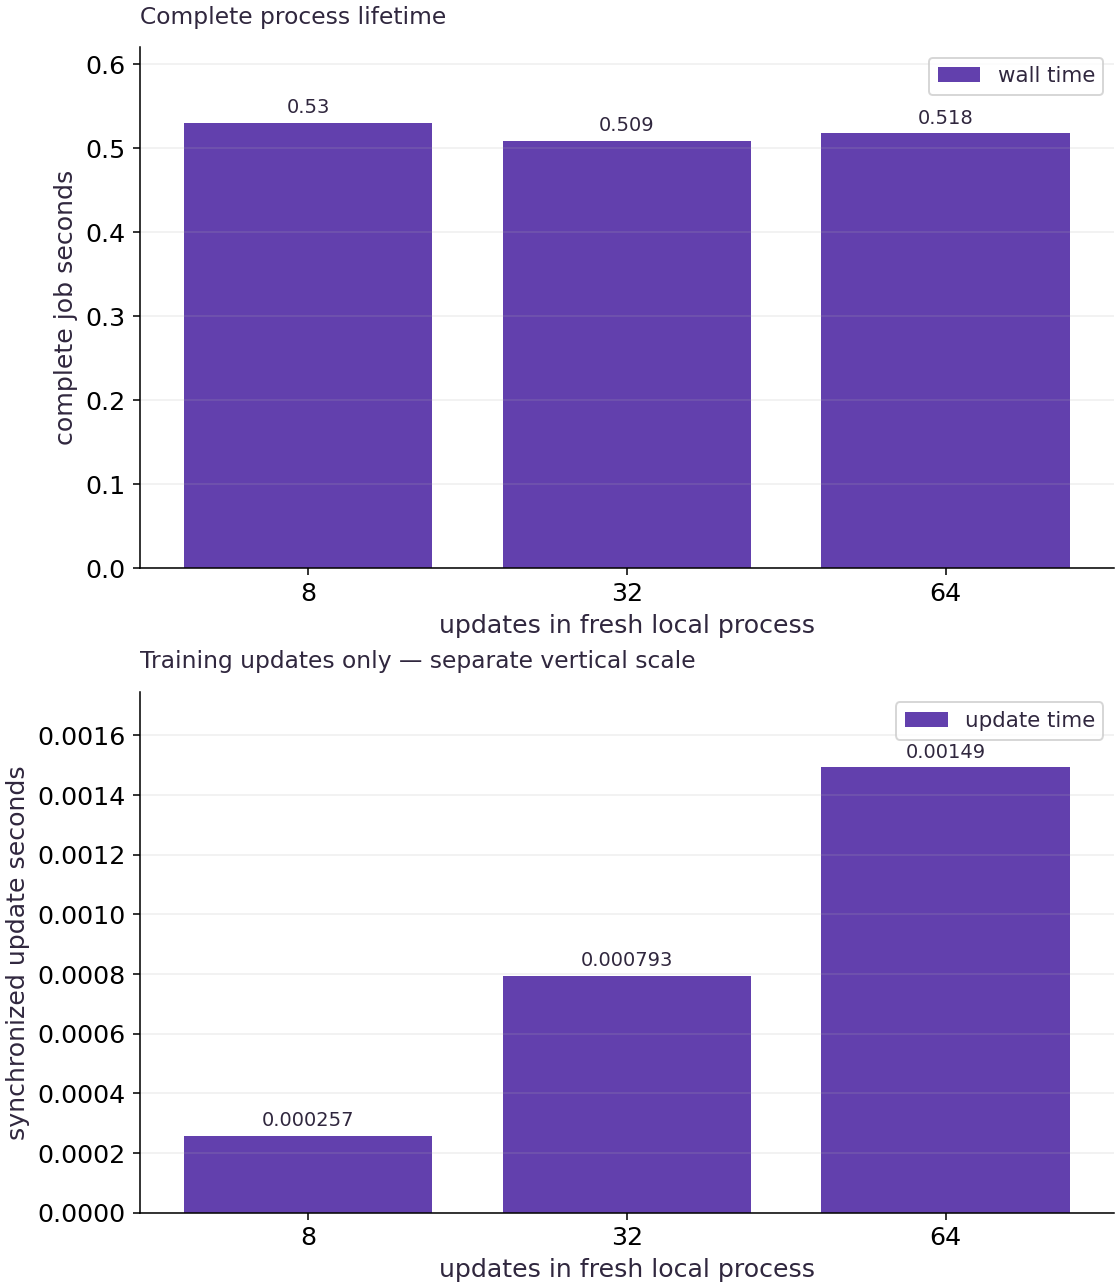

In [8]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories in both panels are actual jobs with $8$, $32$ and $64$ updates. The upper panel shows complete supervisor wall time in seconds. The lower panel shows the sum of synchronized update times in seconds. The panels use separate linear vertical scales, so compare their labeled numerical values rather than bar heights across panels. The labels retain the actual measurements from this run.

### Connect it to the computation

The lower-panel values are much smaller than the complete-job values because startup, compilation, logging and checkpoint writes are outside the update timer. Calculate each pair’s ratio from its labels to see how much of the short job is spent in measured updates. The ratio can be large for such small workloads. Host scheduling and filesystem work vary, so close wall-time values need not increase monotonically with update count. This figure explains timing boundaries and startup amortization; it does not measure hardware utilization or prove scaling on an accelerator.

## Check units with known arithmetic

Predict: What load and minimum worker count follow from $90$-second jobs arriving $80$ times per hour?

In [9]:
known=capacity(90.,80.,4,2.,.25)
assert known['offered_worker_hours_per_hour']==2.
assert known['load_fraction']==.5
assert known['minimum_workers_with_reserve']==3
assert known['hypothetical_cost_per_job']==.05
assert known['hourly_budget']==8.

Expected: Demand, load, reserve and cost match a hand calculation.

This independent arithmetic checks the calculator without treating invented inputs as measured infrastructure.

## Double the arrivals without changing the job

Predict: Does doubling demand require a proportional change in measured update speed?

In [10]:
one=capacity(measured,600,2,1.5,.25)
two=capacity(measured,1200,2,1.5,.25)
assert abs(two['load_fraction']-2*one['load_fraction'])<1e-12
assert two['hypothetical_cost_per_job']==one['hypothetical_cost_per_job']
print('nominal load at two demand scenarios:',one['load_fraction'],two['load_fraction'])

nominal load at two demand scenarios: 0.04419361109224459 0.08838722218448918


Expected: Nominal load doubles while per-job active-time cost stays fixed under the same simple model.

Demand changes the required capacity; it does not automatically make each job faster or slower in a model without contention.

## Your exercise

Using the measured service-time input, calculate the minimum worker count for $1200$ arrivals per hour with $40$% reserve, then independently verify that the chosen count satisfies the load bound.

In [11]:
# Write your attempt here.

## Reference solution

Try your own implementation first.

In [12]:
changed=capacity(measured,1200,2,1.5,.4)
required=changed['minimum_workers_with_reserve']
demand=1200*measured/3600
assert demand/required <= .6 + 1e-12
if required>1: assert demand/(required-1) > .6
print('required workers under changed hypothetical reserve:',required)

required workers under changed hypothetical reserve: 1


## Account for failed attempts · Transfer / diagnosis

Assume $100$ completed jobs require $125$ equal-duration attempts. Compare active-time cost per attempt with active-time cost per completion.

Hint: Every attempt consumes resources under this hypothetical model.

In [13]:
# Write your attempt here.

## Reference reasoning

Failure overhead belongs in the budget even when it does not count as successful throughput.

In [14]:
per_attempt=measured*1.5/3600
per_completion=125*per_attempt/100
assert abs(per_completion-1.25*per_attempt)<1e-12

## Reject impossible capacity inputs · Transfer / diagnosis

Try a full reserve, zero workers and a nonfinite measured duration.

Hint: A plan should not silently divide by zero or emit a meaningless worker count.

In [15]:
# Write your attempt here.

## Reference reasoning

Input validation makes the assumptions visible and prevents numeric output from looking authoritative when the inputs are invalid.

In [16]:
for change in [dict(reserve_fraction=1.),dict(workers=0),dict(measured_job_s=float('nan'))]:
    inputs=dict(measured_job_s=measured,arrivals_per_hour=600,workers=2,hourly_rate=1.5);inputs.update(change)
    try:capacity(**inputs)
    except ValueError:pass
    else:raise AssertionError('invalid plan accepted')

## Checkpoint

Which claim is supported by the measured update duty fraction?

1. The fraction of local job wall time inside synchronized updates
2. The accelerator will be occupied by the same fraction
3. The same worker count meets any bursty arrival pattern

## Diagnose

If estimated cost is unexpectedly low, check seconds-to-hours conversion, idle reserved capacity and repeated failed attempts. If worker count looks sufficient but latency is poor, inspect burstiness and service-time variation. If longer jobs look faster per example, separate startup amortization from changes in the compiled update itself.

## Evidence

Keep measured job/update samples and independent unit calculations. Label demand, reserve and price assumptions as hypothetical before deriving a resource plan.

## Carry forward

- Carry units and assumptions through every capacity calculation.
- Measured local duration can inform a bounded model without pretending to establish fleet performance.

## Primary references

- [Python subprocess management](https://docs.python.org/3/library/subprocess.html)
- [Python os.replace and fsync](https://docs.python.org/3/library/os.html#os.replace)
- [JAX asynchronous dispatch and synchronization](https://docs.jax.dev/en/latest/async_dispatch.html)
- [JAX device discovery](https://docs.jax.dev/en/latest/_autosummary/jax.devices.html)